In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,
    precision_score, recall_score, f1_score, roc_curve, precision_recall_curve
)
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Training set:", X_train_res.shape)
print("Testing set:", X_test.shape)
print("Fraud cases in training:", sum(y_train_res))
print("Fraud cases in testing:", sum(y_test))


Training set: (454902, 30)
Testing set: (56962, 30)
Fraud cases in training: 227451
Fraud cases in testing: 98


In [14]:
dataset.head(3)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Time_scaled,Amount_scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,-1.996583,0.244964
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-1.996583,-0.342475
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,-1.996562,1.160686


In [ ]:
sns.scatterplot(x="Time_scaled" ,y = "Amount_scaled", data = dataset , hue ="")

In [2]:
dataset = pd.read_csv(r"E:\doc\creditcard\creditcard.csv")

scaler = StandardScaler()
dataset['Time_scaled'] = scaler.fit_transform(dataset['Time'].values.reshape(-1,1))
dataset['Amount_scaled'] = scaler.fit_transform(dataset['Amount'].values.reshape(-1,1))
dataset = dataset.drop(['Time', 'Amount'], axis=1)

X = dataset.drop("Class", axis=1)
y = dataset["Class"]


In [4]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_res, y_train_res)
y_prob_lr = log_reg.predict_proba(X_test)[:,1]

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)
y_prob_rf = rf.predict_proba(X_test)[:,1]

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
xgb.fit(X_train_res, y_train_res)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]


In [5]:
thresholds = np.arange(0.1, 0.9, 0.01)
models_probs = {
    "LogisticRegression": y_prob_lr,
    "RandomForest": y_prob_rf,
    "XGBoost": y_prob_xgb
}

best_thresholds = {}
for name, y_probs in models_probs.items():
    f1_scores = []
    for t in thresholds:
        y_pred = (y_probs >= t).astype(int)
        f1_scores.append(f1_score(y_test, y_pred))
    best_idx = np.argmax(f1_scores)
    best_thresholds[name] = (thresholds[best_idx], f1_scores[best_idx])

best_thresholds


{'LogisticRegression': (0.8899999999999996, 0.3112701252236136),
 'RandomForest': (0.7199999999999996, 0.8603351955307262),
 'XGBoost': (0.8599999999999995, 0.8512820512820513)}

In [6]:
for name, y_probs in models_probs.items():
    threshold = best_thresholds[name][0]
    y_pred_best = (y_probs >= threshold).astype(int)
    print(f"\n{name} (Threshold={threshold:.2f})")
    print(confusion_matrix(y_test, y_pred_best))
    print(classification_report(y_test, y_pred_best, digits=4))
    print("ROC-AUC:", roc_auc_score(y_test, y_probs))



LogisticRegression (Threshold=0.89)
[[56490   374]
 [   11    87]]
              precision    recall  f1-score   support

           0     0.9998    0.9934    0.9966     56864
           1     0.1887    0.8878    0.3113        98

    accuracy                         0.9932     56962
   macro avg     0.5943    0.9406    0.6539     56962
weighted avg     0.9984    0.9932    0.9954     56962

ROC-AUC: 0.9698482164390798

RandomForest (Threshold=0.72)
[[56860     4]
 [   21    77]]
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56864
           1     0.9506    0.7857    0.8603        98

    accuracy                         0.9996     56962
   macro avg     0.9751    0.8928    0.9301     56962
weighted avg     0.9995    0.9996    0.9995     56962

ROC-AUC: 0.9820294465563377

XGBoost (Threshold=0.86)
[[56850    14]
 [   15    83]]
              precision    recall  f1-score   support

           0     0.9997    0.9998    0.9997     

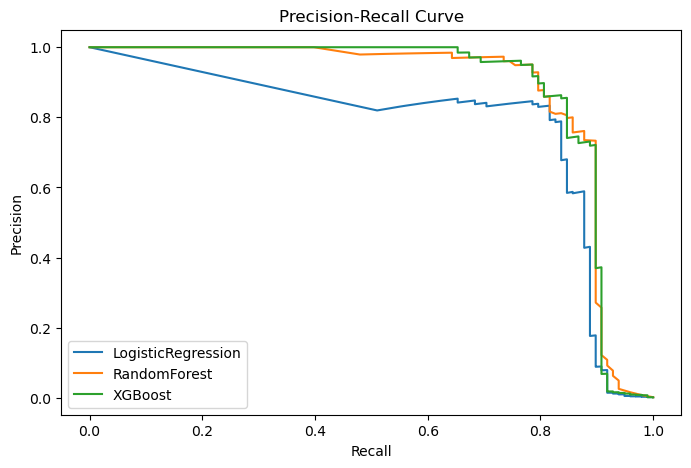

In [7]:
plt.figure(figsize=(8,5))
for name, y_probs in models_probs.items():
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    plt.plot(recall, precision, label=name)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()


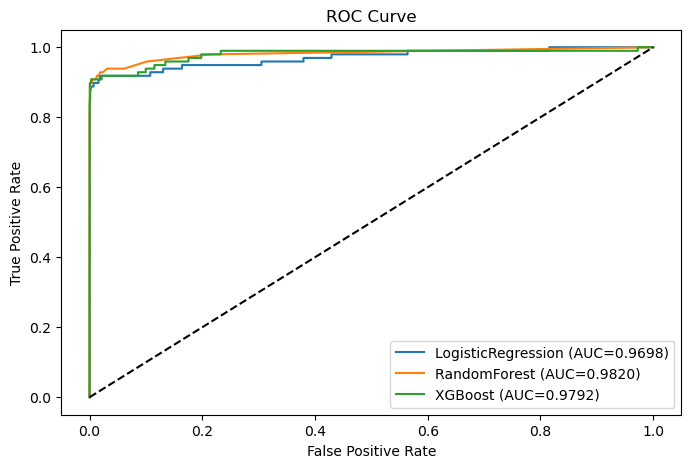

In [8]:
plt.figure(figsize=(8,5))
for name, y_probs in models_probs.items():
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, y_probs):.4f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


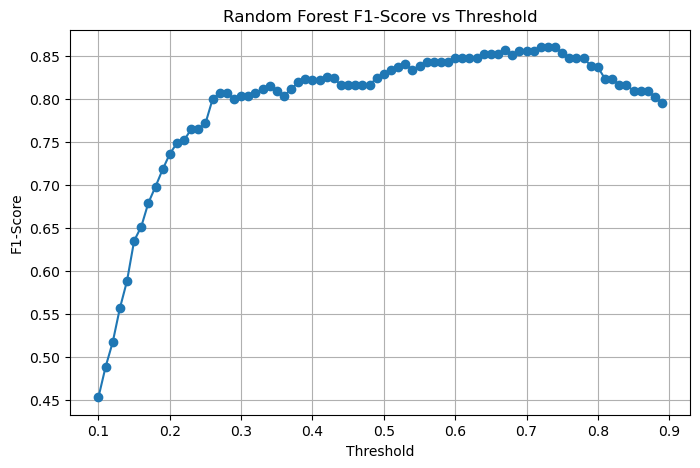

In [9]:
thresholds_plot = np.arange(0.1, 0.9, 0.01)
f1_scores_rf = [f1_score(y_test, (y_prob_rf >= t).astype(int)) for t in thresholds_plot]

plt.figure(figsize=(8,5))
plt.plot(thresholds_plot, f1_scores_rf, marker='o')
plt.xlabel('Threshold')
plt.ylabel('F1-Score')
plt.title('Random Forest F1-Score vs Threshold')
plt.grid(True)
plt.show()


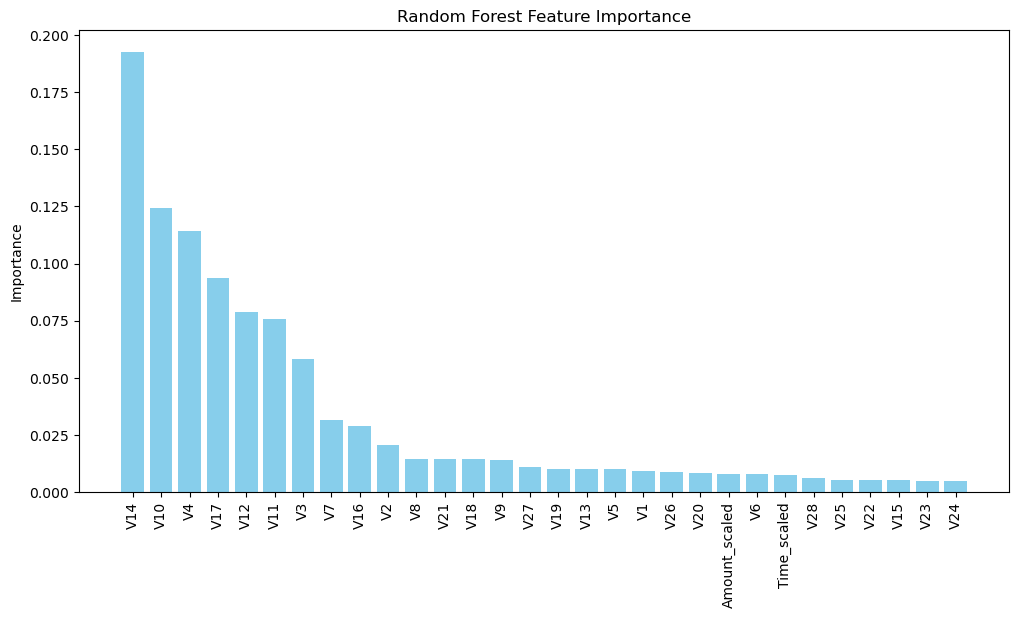

In [10]:
importances = rf.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12,6))
plt.title("Random Forest Feature Importance")
plt.bar(range(len(importances)), importances[indices], color="skyblue", align="center")
plt.xticks(range(len(importances)), [features[i] for i in indices], rotation=90)
plt.ylabel("Importance")
plt.show()


<Figure size 1200x600 with 0 Axes>

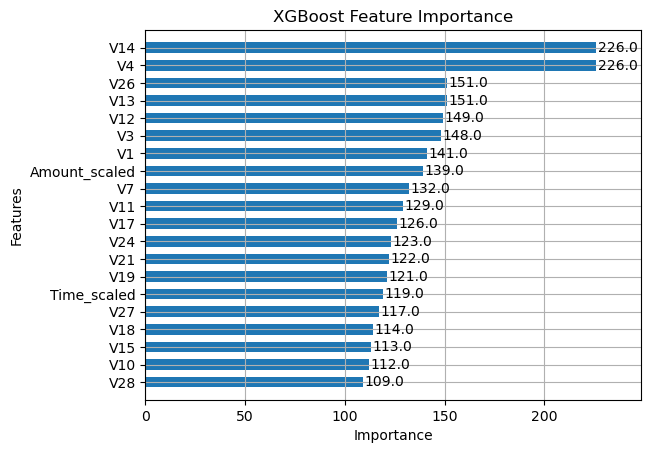

In [11]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.figure(figsize=(12,6))
plot_importance(xgb, max_num_features=20, importance_type='weight', xlabel='Importance', ylabel='Features', height=0.6)
plt.title("XGBoost Feature Importance")
plt.show()


In [12]:
joblib.dump(rf, "final_fraud_model.pkl")
print("Final Random Forest model saved as final_fraud_model.pkl")


Final Random Forest model saved as final_fraud_model.pkl


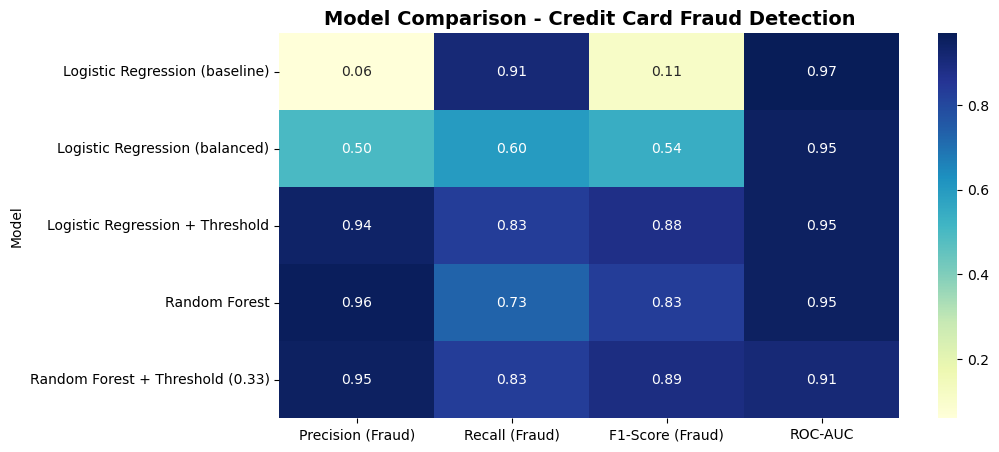

In [13]:
data = {
    "Model": [
        "Logistic Regression (baseline)",
        "Logistic Regression (balanced)",
        "Logistic Regression + Threshold",
        "Random Forest",
        "Random Forest + Threshold (0.33)"
    ],
    "Precision (Fraud)": [0.06, 0.50, 0.94, 0.96, 0.95],
    "Recall (Fraud)": [0.91, 0.60, 0.83, 0.73, 0.83],
    "F1-Score (Fraud)": [0.11, 0.54, 0.88, 0.83, 0.89],
    "ROC-AUC": [0.97, 0.95, 0.95, 0.95, 0.91]
}

df_comp = pd.DataFrame(data)
df_comp.set_index("Model", inplace=True)
plt.figure(figsize=(10,5))
sns.heatmap(df_comp, annot=True, cmap="YlGnBu", fmt=".2f", cbar=True)
plt.title("Model Comparison - Credit Card Fraud Detection", fontsize=14, weight="bold")
plt.yticks(rotation=0)
plt.show()
